* Mask radar data for hovmoller analysis (Cairns & Willis)
* Plots of overlayed satellite and radar data

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import metpy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
from netCDF4 import Dataset
import pyproj
import os
import glob
from datetime import datetime
import seaborn as sns
import netCDF4
from netCDF4 import Dataset
from metpy.units import units
import dask
import xarray as xr
from shapely import Polygon
import regionmask
import geopandas as gpd
import logging
import dask
from dask.distributed import Client
from dask import delayed
import functools
import zipfile
import tempfile
import wradlib as wrl
sys.path.append(os.path.join(r"/home/563/ac9768/GBR/scripts/Paper_figures")) 
# from define_wind_regimes import wind_times

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")

In [4]:
client = Client(n_workers=28,threads_per_worker=1,memory_limit=None,silence_logs=logging.ERROR,dashboard_address='8787') 
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39691,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43695,Total threads: 1
Dashboard: /proxy/44327/status,Memory: 0 B
Nanny: tcp://127.0.0.1:42869,


In [5]:
# # use barra-r2 wind directions to find defined wind regime times
# ne_towns,se_towns,sw_towns,nw_towns = wind_times(barra_towns)
# ne_cairns,se_cairns,sw_cairns,nw_cairns = wind_times(barra_cairns)
# ne_willis,se_willis,sw_willis,nw_willis = wind_times(barra_willis)

In [6]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [7]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

# Read in through dask radar datasets

In [7]:
# 22/04/26 - rain rate variable pre-2020 possibly deleted. This function opens 'reflectivity' variable to derive rainrate - however this is reflectivity at 2.5km
# def path_to_radar_ds(radar_site_no: str):
#     """Create list of file paths for the chosen radar ID.
#     List selects JFMA data between 2012-01 and 2022-04

#     Args:
#         radar_site_no (str): String of radar ID number; cairns = "19", willis island = "41"

#     Returns:
#         list: List of file paths strings
#     """
#     list = ["202201","202202","202203","202204","202101","202102","202103","202104","202001","202002","202003","202004","201901","201902","201903","201904",
#            "201801","201802","201803","201804","201701","201702","201703","201704","201601","201602","201603","201604","201501","201502",
#            "201503","201504","201401","201402","201403","201404","201301","201302","201303","201304","201201","201202","201203","201204",
#           ] 
#     files_list = []
#     for i in list:
#         fp = "/g/data/rq0/level_2/"+radar_site_no+"/REFLECTIVITY/"
#         all_files = [os.path.join(root, f) for root, _, files in os.walk(fp)
#             for f in files
#             if f.startswith(radar_site_no+'_'+i) and f.endswith('.nc')]
#         files_list.extend(all_files)
#     files_list.sort()
#     return files_list

In [16]:
# Old functions - data no longer here; doesn't need to convert rain rate
# def path_to_radar_ds(radar_site_no: str):
#     """Create list of file paths for the chosen radar ID.
#     List selects JFMA data between 2012-01 and 2022-04

#     Args:
#         radar_site_no (str): String of radar ID number; cairns = "19", willis island = "41"

#     Returns:
#         list: List of file paths strings
#     """
#     list = ["202201","202202","202203","202204","202101","202102","202103","202104","202001","202002","202003","202004","201901","201902","201903","201904",
#            "201801","201802","201803","201804","201701","201702","201703","201704","201601","201602","201603","201604","201501","201502",
#            "201503","201504","201401","201402","201403","201404","201301","201302","201303","201304","201201","201202","201203","201204",
#           ] 
#     files_list = []
#     for i in list:
#         fp = "/g/data/rq0/admin/level_2_decomissioned_fields/"+radar_site_no+"/RAINRATE/"
#         all_files = [os.path.join(root, f) for root, _, files in os.walk(fp)
#             for f in files
#             if f.startswith(radar_site_no+'_'+i) and f.endswith('.nc')]
#         files_list.extend(all_files)
#     files_list.sort()
#     return files_list

# def radar_ds_subset(file_list: list):
#     """Define and open a subset of the radar domain: the Hovmoller slice - taking the full longitudinal range and a latitudinal subset (-17S - -16.6S).
#     1. Opens a single file to define the y values corresponding to the range (-17S, -16.6S)
#     2. Define a preprocesser - apply quality control mask and select y values (x values are also selected to remove a few artefacts on the RHS of the Cairns domain)
#     3. Return subset dataset

#     Args:
#         file_list (list): list of radar files to take subset

#     Returns:
#         xr.Dataset: Hovmoller slice rain rate data for the full time period
#     """    
#     with xr.open_dataset(file_list[0]) as ref_ds:
#         lat_mean_along_x = ref_ds.latitude.mean(dim='x')
#         lat_band = ((lat_mean_along_x > -17) & (lat_mean_along_x < -16.6)).compute()
#         y_vals = ref_ds.y.where(lat_band, drop=True).values  # Get hovmoller slice y values

#     def _preprocess(ds):
#         # Apply quality control
#         ds = ds.where(ds.isfile == 1)

#         # Subset rainrate and Hovmoller slice
#         rain = ds.rainrate.sel(y=y_vals, x=slice(-150000, 140000))
        
#         return rain
    
#     return xr.open_mfdataset(
#         file_list,
#         preprocess=_preprocess,
#         parallel=True, 
#         combine="by_coords")

# def mask_radar_data(file_list: list, cairns: bool = None):
#     """Mask subset rain rate dataset 
#     1. Open subset data twice
#     - mean_ds is used to find invalid points (where no measurements are taken)
#     - ds is used to fill all nans as zeroes (where no rainfall is measured --> set to zero instead of nan)
#     2. Apply masks 

#     Args:
#         file_list (list): List of file paths strings
#         cairns (bool): Defaults to None. It true, beam blockage mask is also applied to the final dataset

#     Returns:
#         xr.Dataset: Xarray dataset of mean rain rate across the narrow latitude slice for each time step (with masks applied)
#     """
#     ds = radar_ds_subset(file_list)
#     mean_ds = radar_ds_subset(file_list)

#     # 1a. Identify regions where rainrate is *always* NaN (i.e., no measurements ever)
#     valid_mask = mean_ds.rainrate.mean('time', skipna=True).notnull()
#     if cairns:
#         bb_mask = mean_ds.rainrate.mean('time') >= 1.2
#         mask = valid_mask & bb_mask
#     else:
#         mask = valid_mask

#     # 1b. Fill NaNs (individual missing values) with 0 --> raining+non-raining times/points
#     rain = ds.rainrate.fillna(0)

#     # 2. Apply the valid data mask (nan if always nan over time) and the beam blockage mask
#     rain = rain.where(mask)
#     return rain.mean('y')

In [29]:
# Using 2.5km reflectivity
# def preprocess_convert_dbz_to_rainrate(file_list: list, lat_data: xr.Dataset, a: float, b: float) -> xr.Dataset:
#     """
#     Convert reflectivity (dBZ) to rain rate (mm/h) using the Z-R relationship:
#         Z = a * R^b  →  R = (Z / a)^(1/b)
#     Args:
#         file_list: list of .nc file paths
#         a:         Z-R coefficient
#         b:         Z-R exponent
#     Returns:
#         xarray Dataset with 'rainrate' variable (mm/h)
#     """
#     with xr.open_dataset(lat_data) as ref_ds:
#         lat_mean_along_x = ref_ds.latitude.mean(dim='x')
#         lat_band = ((lat_mean_along_x > -17) & (lat_mean_along_x < -16.6)).compute()
#         y_vals = ref_ds.y.where(lat_band, drop=True).values

#     def _preprocess(ds, a, b):
#         # ds = ds.where(ds.isfile == 1) # not in new ground reflectivity ds
#         rain = ds.reflectivity.sel(y=y_vals, x=slice(-150000, 140000))
#         dBZ = rain                  # https://docs.wradlib.org/en/2.3.0/notebooks/basics/wradlib_get_rainfall.html
#         Z = wrl.trafo.idecibel(dBZ) #
#         R = wrl.zr.z_to_r(Z, a=a, b=b)
#         # Z = 10 ** (rain / 10)
#         # R = (Z / a) ** (1 / b)
#         # R = R.where(rain > 0, other=0.0)
#         ds_out = R.to_dataset(name='rainrate')
#         ds_out['rainrate'].attrs.update({'units': 'mm/h', 'long_name': 'rain rate'})
#         return ds_out

#     return xr.open_mfdataset(
#         file_list,
#         preprocess=functools.partial(_preprocess, a=a, b=b),
#         parallel=True,
#         combine="by_coords",
#     )

In [ ]:
# conversion of reflectivity to rainrate --- not used for hovmoller plots which also have preprocessing step
def convert_dbz_to_rainrate(file_list: list, ds: xr.Dataset, a: float, b: float ) -> xr.Dataset:
    """
    Convert reflectivity (dBZ) to rain rate (mm/h) using the Z-R relationship:
        Z = a * R^b  →  R = (Z / a)^(1/b)

    Args:
        ds:  xarray Dataset with a 'dbZ' variable (reflectivity in dBZ)
        a:   Z-R coefficient (default 200, Marshall-Palmer)
        b:   Z-R exponent   (default 1.6, Marshall-Palmer)

    Returns:
        xarray Dataset with added 'rain_rate' variable (mm/h)
    """
    # 1. dBZ → linear Z (mm^6/m^3)
    Z = 10 ** (ds['reflectivity'] / 10)

    # 2. Z-R inversion: R = (Z / a)^(1/b)
    R = (Z / a) ** (1 / b)

    # 3. Mask negative dBZ (no rain) and unreasonably high rain rates
    R = R.where(ds['reflectivity'] > 0, other=0.0)

    # 4. Assign back to dataset
    ds_out = ds.assign(rainrate=R)
    ds_out['rainrate'].attrs.update({'units': 'mm/h', 'long_name': 'rain rate'})

    return ds_out

In [6]:
# Opening updated historical ground reflectivity files - conversion of zip to nc files - only run once
def path_to_radar_ds_zip2nc(radar_site_no: str):
    """Create list of file paths for the chosen radar ID.
    Walks the full prcp-crate directory and returns all .zip-contained .nc files.

    Args:
        radar_site_no (str): String of radar ID number; cairns = "19", willis island = "41"
    Returns:
        list: List of extracted .nc file path strings
    """
    year  = ['2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022']
    month = ['01','02','03','04']
    zip_list = sorted(
        f
        for y in year
        for m in month
        for f in glob.glob(f"/g/data/rq0/hist_gndrefl/v2026/{radar_site_no}/{y}/{radar_site_no}_{y}{m}*.zip")
    )

    if not zip_list:
        raise FileNotFoundError(f"No .zip files found for radar site '{radar_site_no}' — check the path.")

    tmp_dir = tempfile.mkdtemp(prefix=f"radar_{radar_site_no}_", dir="/scratch/v46/ac9768/radar_grndref/")
    nc_files = []

    for zp in zip_list:
        with zipfile.ZipFile(zp, 'r') as zf:
            for member in zf.namelist():
                if member.endswith('.nc'):
                    zf.extract(member, tmp_dir)
                    nc_files.append(os.path.join(tmp_dir, member))

    nc_files.sort()
    return nc_files

In [7]:
# to unzip files and convert to nc
towns_radar_files = path_to_radar_ds_zip2nc("73")
# cairns_radar_files = path_to_radar_ds_zip2nc("19")
# willis_radar_files = path_to_radar_ds_zip2nc("41")

In [11]:
######### Open nc files 
def path_to_radar_ds(radar_site_no: str):
    """Create list of file paths for the chosen radar ID.
    Walks the full prcp-crate directory and returns all .zip-contained .nc files.

    Args:
        radar_site_no (str): String of radar ID number; cairns = "19", willis island = "41"
    Returns:
        list: List of extracted .nc file path strings
    """
    files = sorted(glob.glob(f"/scratch/v46/ac9768/radar_grndref/radar_{radar_site_no}_*/*.nc"))
    return files

In [ ]:
# def preprocess_and_save_zarr(file_list: list, a: float, b: float, out_path: str) -> None:
#     """
#     Preprocess radar reflectivity files, convert to rain rate, and save to zarr.
#     Args:
#         file_list: list of .nc file paths
#         a:         Z-R coefficient
#         b:         Z-R exponent
#         out_path:  output zarr store path
#     """
#     import zarr

#     # Compute projection grid once from reference file
#     with xr.open_dataset(file_list[0]) as ref:
#         x_grid, y_grid = np.meshgrid(ref.x.data, ref.y.data)
#         proj = pyproj.Proj(
#             proj='aea',
#             lat_1=ref.proj.standard_parallel[0],
#             lat_2=ref.proj.standard_parallel[1],
#             lat_0=ref.proj.latitude_of_projection_origin,
#             lon_0=ref.proj.longitude_of_central_meridian,
#             x_0=0, y_0=0
#         )
#         lon_grid, lat_grid = proj(x_grid * 1000, y_grid * 1000, inverse=True)

#     def _preprocess(ds, a, b, lat_grid, lon_grid):
#         lat_da   = xr.DataArray(lat_grid, dims=['y', 'x'])
#         lon_da   = xr.DataArray(lon_grid, dims=['y', 'x'])
#         lat_band = (lat_grid > -17) & (lat_grid < -16.6)
#         dBZ = ds.reflectivity.where(lat_band)
#         Z   = wrl.trafo.idecibel(dBZ)
#         R   = wrl.zr.z_to_r(Z, a=a, b=b)
#         ds  = ds.assign(lat=lat_da, lon=lon_da, rainrate=R)
#         ds['rainrate'].attrs.update({'units': 'mm/h', 'long_name': 'rain rate'})
#         if 'valid_time' in ds:
#             ds = ds.rename({'valid_time': 'time'}).set_coords('time')
#             if 'time' not in ds.dims:
#                 ds = ds.expand_dims('time')
#         return ds

#     ds = xr.open_mfdataset(
#         file_list,
#         preprocess=functools.partial(_preprocess, a=a, b=b,
#                                      lat_grid=lat_grid, lon_grid=lon_grid),
#         parallel=True,
#         combine="by_coords",
#     )

#     # Keep only rainrate, lat, lon — drop raw reflectivity and other vars
#     ds_out = ds[['rainrate', 'lat', 'lon']]

#     # Save to zarr with compression
#     encoding = {
#         'rainrate': {
#             'dtype': 'float32',
#             'compressor': zarr.Blosc(cname='zstd', clevel=3, shuffle=2),
#         },
#         'lat': {'dtype': 'float32'},
#         'lon': {'dtype': 'float32'},
#     }

#     print(f"Saving to {out_path} ...")
#     ds_out.to_zarr(out_path, mode='w', encoding=encoding)
#     print(f"Done.")


# # --- Run once per radar site ---
# cairns_radar_files = path_to_radar_ds("19")
# willis_radar_files = path_to_radar_ds("41")

# cairns_zarr = '/scratch/v46/ac9768/radar/cairns_rainrate.zarr'
# willis_zarr = '/scratch/v46/ac9768/radar/willis_rainrate.zarr'

# if not os.path.exists(cairns_zarr):
#     preprocess_and_save_zarr(cairns_radar_files, a=185.5, b=1.22, out_path=cairns_zarr)

# # if not os.path.exists(willis_zarr):
# #     preprocess_and_save_zarr(willis_radar_files, a=171.5, b=1.22, out_path=willis_zarr)

# # --- Load from zarr for all subsequent work ---
# # cairns_ds = xr.open_zarr(cairns_zarr)
# # willis_ds = xr.open_zarr(willis_zarr)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 158.03 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [9]:
def preprocess_convert_dbz_to_rainrate(file_list: list, a: float, b: float) -> xr.Dataset:
    """
    Convert reflectivity (dBZ) to rain rate (mm/h) using the Z-R relationship:
        Z = a * R^b  →  R = (Z / a)^(1/b)
    Args:
        file_list: list of .nc file paths
        a:         Z-R coefficient
        b:         Z-R exponent
    Returns:
        xarray Dataset with 'rainrate' variable (mm/h)
    """
    # Compute projection grid once from reference file
    with xr.open_dataset(file_list[0]) as ref:
        x_grid, y_grid = np.meshgrid(ref.x.data, ref.y.data)
        proj = pyproj.Proj(
            proj='aea',
            lat_1=ref.proj.standard_parallel[0],
            lat_2=ref.proj.standard_parallel[1],
            lat_0=ref.proj.latitude_of_projection_origin,
            lon_0=ref.proj.longitude_of_central_meridian,
            x_0=0, y_0=0
        )
        lon_grid, lat_grid = proj(x_grid * 1000, y_grid * 1000, inverse=True)

    def _preprocess(ds, a, b, lat_grid, lon_grid):
        lat_da   = xr.DataArray(lat_grid, dims=['y', 'x'])
        lon_da   = xr.DataArray(lon_grid, dims=['y', 'x'])
        lat_band = (lat_grid > -17) & (lat_grid < -16.6)

        dBZ = ds.reflectivity.where(lat_band)
        Z   = wrl.trafo.idecibel(dBZ)
        R   = wrl.zr.z_to_r(Z, a=a, b=b)

        ds = ds.assign(lat=lat_da, lon=lon_da, rainrate=R)
        ds['rainrate'].attrs.update({'units': 'mm/h', 'long_name': 'rain rate'})

        if 'valid_time' in ds:
            ds = ds.rename({'valid_time': 'time'}).set_coords('time')
            if 'time' not in ds.dims:
                ds = ds.expand_dims('time')

        return ds

    return xr.open_mfdataset(
        file_list,
        preprocess=functools.partial(_preprocess, a=a, b=b,
                                     lat_grid=lat_grid,
                                     lon_grid=lon_grid),
        parallel=True,
        combine="by_coords",
    )

In [10]:
def mask_radar_data(file_list: list, a,b,cairns: bool = None):
    """Mask subset rain rate dataset 
    1. Open subset data twice
    - mean_ds is used to find invalid points (where no measurements are taken)
    - ds is used to fill all nans as zeroes (where no rainfall is measured --> set to zero instead of nan)
    2. Apply masks 

    Args:
        file_list (list): List of file paths strings
        cairns (bool): Defaults to None. It true, beam blockage mask is also applied to the final dataset

    Returns:
        xr.Dataset: Xarray dataset of mean rain rate across the narrow latitude slice for each time step (with masks applied)
    """
    ds = preprocess_convert_dbz_to_rainrate(file_list, a, b)
    mean_ds = preprocess_convert_dbz_to_rainrate(file_list, a, b)

    # 1a. Identify regions where rainrate is *always* NaN (i.e., no measurements ever)
    valid_mask = mean_ds.rainrate.mean('time', skipna=True).notnull()
    if cairns:
        bb_mask = mean_ds.rainrate.mean('time') >= 1.2
        mask = valid_mask & bb_mask
    else:
        mask = valid_mask

    # 1b. Fill NaNs (individual missing values) with 0 --> raining+non-raining times/points
    rain = ds.rainrate.fillna(0)

    # 2. Apply the valid data mask (nan if always nan over time) and the beam blockage mask
    rain = rain.where(mask)
    return rain.mean('y')

In [11]:
def get_radar_under_wind_regimes(radar_ds: xr.Dataset,barra_regimes_ds: xr.Dataset):
    """Select masked subset of radar data for times under each wind regime. 
    1. Defined BARRA-R2 regimes are used to define each hour time-step
    - Radar data +30/-30 min from each hour defined as *regime is selected and appended
    2. Radar data under each regime is concatenated, groupby hour and taken mean over each hour
    3. Hourly timesteps adjusted for AEDT time

    Args:
        radar_ds (xr.Dataset): Subset and masked radar rainrate dataset (mean over latitude slice taken)
        barra_regimes_ds (xr.Dataset): BARRA-R2 regime dataset

    Returns:
        xr.DataArray: Xarray data array of mean rain rate (doubled in the 'hour' axis for plotting over 48 hours) 
    """
    # 1. use barra-r2 wind regimes to define times, take +30/-30min of the hour
    window_size = pd.Timedelta(minutes=30)
    select_data = []
    for time in barra_regimes_ds:
        window_start = time - window_size
        window_end = time + window_size
        data_in_window = radar_ds.sel(time=slice(window_start,window_end))
        select_data.append(data_in_window)

    results = xr.concat(select_data,dim='time').drop_duplicates(dim='time')
    grpby = results.groupby('time.hour').mean('time')
    roll = grpby.roll(hour=11,roll_coords=False)
    return xr.concat([roll, roll], dim='hour')

<xarray.Dataset> Size: 36B
Dimensions:       ()
Data variables:
    reflectivity  float64 8B 19.94
    longitude     float64 8B 144.3
    latitude      float64 8B -18.17
    isfile        int32 4B 1
    rainrate      float64 8B 0.0
Attributes: (12/56)
    summary:                       Level 2 dataset from the Australian radar ...
    history:                       created by Joshua Soderholm on gadi.nci.or...
    acknowledgement:               This work is support by the Bureau of Mete...
    institution:                   Bureau of Meteorology
    keywords:                      radar, Doppler, dual-polarization
    licence:                       CC4.0-BY-NC (if the latest dataset licence...
    ...                            ...
    geospatial_vertical_min:       2500
    geospatial_vertical_max:       2500
    comments:                      Radar reflectivity has not been corrected ...
    geospatial_projection:         Azimuthal equidistant projection
    geospatial_vertical_positive:  up
    geospatial_vertical_units:     m

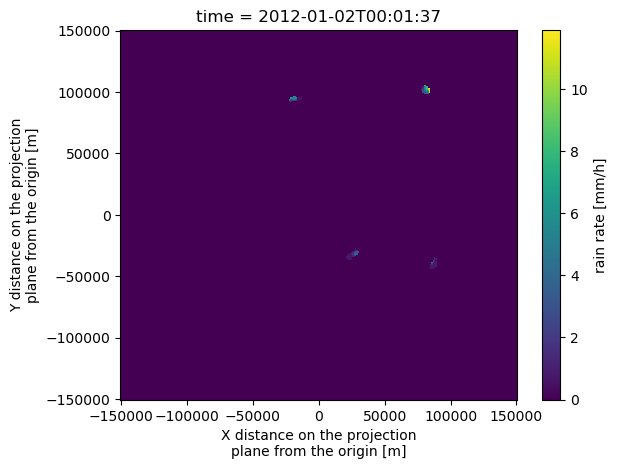

In [33]:
ds_test = xr.open_dataset(cairns_radar_files[1])
rainrate = convert_dbz_to_rainrate(ds_test,185.5,1.22)
rainrate.isel(time=0).rainrate.plot()
rainrate.min()

In [ ]:
with xr.open_dataset(cairns_radar_files[3]) as ds:
    radar_lat = ds.proj.latitude_of_projection_origin
    radar_lon = ds.proj.longitude_of_central_meridian
    x_grid, y_grid = np.meshgrid(ds.x.data, ds.y.data)

    #create latlon projection
    proj = pyproj.Proj(proj='aea', lat_1=ds.proj.standard_parallel[0], lat_2=ds.proj.standard_parallel[1],
                            lat_0=ds.proj.latitude_of_projection_origin, lon_0=ds.proj.longitude_of_central_meridian,
                            x_0=0, y_0=0)
    
    lon_grid, lat_grid = proj(x_grid*1000, y_grid*1000, inverse=True)
    lat_band = ((lat_grid > -17) & (lat_grid < -16.6))
    reflectivity = ds.reflectivity.where(lat_band)

    # add lat lon as vars to dataset
    lat_da = xr.DataArray(lat_grid, dims=['y', 'x'])
    lon_da = xr.DataArray(lon_grid, dims=['y', 'x'])

    # Select latitudinal slice & calculate rainrate
    lat_band = ((lat_da > -17) & (lat_da < -16.6))
    dBZ = ds.reflectivity.where(lat_band)                 # https://docs.wradlib.org/en/2.3.0/notebooks/basics/wradlib_get_rainfall.html
    Z = wrl.trafo.idecibel(dBZ) 
    R = wrl.zr.z_to_r(Z, a=155, b=1.2)

    # add rain rate, lat and lon as new variables
    ds = ds.assign(lat=lat_da, lon=lon_da, rainrate=R)
    # ds['rainrate'] = R
    ds['rainrate'].attrs.update({'units': 'mm/h', 'long_name': 'rain rate'})

    # rename time variable
    # if 'valid_time' in ds:
    #     time = ds.valid_time.values
    #     ds = ds.assign(valid_time=time)
    #     ds = ds.rename({'valid_time': 'time'}).set_coords('time')
    #     ds.time = ds.set_dim('time')
    # Rename valid_time → time and promote to dimension coordinate
    if 'valid_time' in ds:
        ds = ds.rename({'valid_time': 'time'}).set_coords('time')
        if 'time' not in ds.dims:
            ds = ds.expand_dims('time')
ds.rainrate.mean('y').plot()

<xarray.Dataset> Size: 6MB
Dimensions:       (y: 600, n2: 2, x: 600)
Coordinates:
  * y             (y) float64 5kB 149.8 149.2 148.8 ... -148.8 -149.2 -149.8
  * x             (x) float64 5kB -149.8 -149.2 -148.8 ... 148.8 149.2 149.8
    valid_time    datetime64[ns] 8B 2012-01-01T00:32:00
Dimensions without coordinates: n2
Data variables:
    proj          int8 1B ...
    y_bounds      (y, n2) float64 10kB ...
    x_bounds      (x, n2) float64 10kB ...
    reflectivity  (y, x) float64 3MB ...
    error         (y, x) float64 3MB ...
Attributes:
    Conventions:           CF-1.7
    title:                 Corrected Reflectivity at Ground
    institution:           Bureau of Meteorology
    licence:               CC4.0-BY-NC (if the latest dataset licence if diff...
    release:               April 2026 (version 2.0)
    source:                Weather Radar
    station_id:            19
    station_name:          Cairns
    calibration_estimate:  7.19

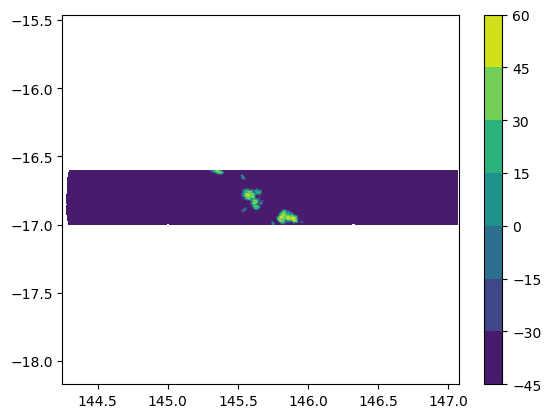

In [146]:
with xr.open_dataset(cairns_radar_files[3]) as ds:
    radar_lat = ds.proj.latitude_of_projection_origin
    radar_lon = ds.proj.longitude_of_central_meridian
    x_grid, y_grid = np.meshgrid(ds.x.data, ds.y.data)

    #create latlon projection
    proj = pyproj.Proj(proj='aea', lat_1=ds.proj.standard_parallel[0], lat_2=ds.proj.standard_parallel[1],
                            lat_0=ds.proj.latitude_of_projection_origin, lon_0=ds.proj.longitude_of_central_meridian,
                            x_0=0, y_0=0)
    
    lon_grid, lat_grid = proj(x_grid*1000, y_grid*1000, inverse=True)
    lat_band = ((lat_grid > -17) & (lat_grid < -16.6))
    reflectivity = ds.reflectivity.where(lat_band)
    ds = ds.assign_coords(valid_time=ds.valid_time.values)
    

plt.contourf(lon_grid,lat_grid,reflectivity)
plt.colorbar()

lat_band = ((y_grid > -17) & (y_grid < -16.6))
y = xr.DataArray(y_grid)
y_vals = y.where(lat_band)
ds

In [28]:
%time
# historical ground reflectivity dataset convert to nc and store in scratch/v46/ac9768/radar_grndref
cairns_radar_files = path_to_radar_ds("19")
willis_radar_files = path_to_radar_ds("41")
lat_dataC = '/g/data/rq0/level_2/19/REFLECTIVITY/19_20000227_reflectivity.nc'
lat_dataW = '/g/data/rq0/level_2/41/REFLECTIVITY/41_19981213_reflectivity.nc'

cairns_ds = mask_radar_data(cairns_radar_files[0:3000],a=185.5,b=1.22,cairns=True)
# print('cairns processed')
# willis_ds = mask_radar_data(willis_radar_files,lat_dataW,171.5,1.22)
# cairns_ds = mask_radar_data(cairns_radar_files,cairns=True)
# willis_ds = mask_radar_data(willis_radar_files)

CPU times: user 2 μs, sys: 7 μs, total: 9 μs
Wall time: 16.9 μs


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 14.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


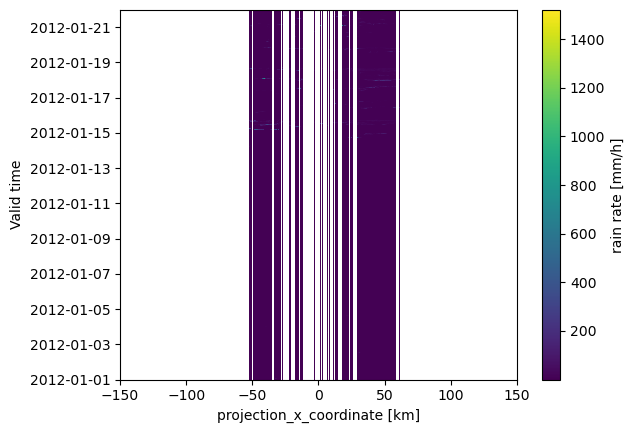

In [29]:
cairns_ds.plot()

In [12]:
# make dictionaries for regime and radar data
wind_regimes = {
    'cairns': {
        'ne': ne_cairns,
        'se': se_cairns,
        'sw': sw_cairns,
        'nw': nw_cairns,
    },
    # willis island regime times differ slightly to Cairns --> for comparison and analysis of propagation the Cairns regime time periods are used
    'willis': {
        'ne': ne_cairns,
        'se': se_cairns,
        'sw': sw_cairns,
        'nw': nw_cairns,
    },
}

radar_datasets = {
    'cairns': cairns_ds,
    'willis': willis_ds,
}

In [13]:
# create dictionary for resulting Hovmoller sliced radar data (masked and time adjusted) under BARRA-R2 regimes
results = {}

for domain, regime_dict in wind_regimes.items():
    results[domain] = {}
    for regime, regime_periods in regime_dict.items():
        results[domain][regime] = get_radar_under_wind_regimes(radar_datasets[domain],regime_periods)

# redo radar scripts

In [8]:
def path_to_radar_ds(radar_site_no: str):
    """Create list of file paths for the chosen radar ID.
    Walks the radar_grndref directory and returns all .nc files.

    Args:
        radar_site_no (str): String of radar ID number; cairns = "19", willis island = "41"
    Returns:
        list: List of extracted .nc file path strings
    """
    files = sorted(glob.glob(f"/scratch/v46/ac9768/radar_grndref/radar_{radar_site_no}_*/*.nc"))
    return files

In [10]:
# ============================================================
# STEP 2 — Load zarr, apply masks, select lat band, mean over y
# Run each session. Fast — loads from zarr, no zip extraction.
# ============================================================

def mask_radar_data(
    zarr_path: str,
    lat_min: float = -17.0,
    lat_max: float = -16.6,
    cairns: bool = False,
    bb_threshold: float = 1.2,
) -> xr.DataArray:
    """
    Load zarr rainrate, apply lat band selection and validity masks,
    return mean over y (Hovmoller slice).

    Args:
        zarr_path:    path to zarr store from save_rainrate_zarr
        lat_min:      southern lat boundary for Hovmoller slice
        lat_max:      northern lat boundary for Hovmoller slice
        cairns:       if True, apply beam blockage mask
        bb_threshold: beam blockage mask threshold (mm/h mean)
    Returns:
        xr.DataArray: (time, x) mean rain rate along lat slice
    """
    ds = xr.open_zarr(zarr_path).chunk({'time': 100, 'y': -1, 'x': -1})

    # Select lat band using stored lat coordinate
    lat_band = (ds.lat > lat_min) & (ds.lat < lat_max)
    ds = ds.where(lat_band)

    # Compute time-mean once for masking — load only rainrate
    time_mean = ds.rainrate.mean('time', skipna=True).compute()

    # Valid mask: pixels where measurements exist over time
    valid_mask = time_mean.notnull()

    # if cairns:
    #     # Beam blockage mask: pixels with suspiciously high mean rain rate
    #     bb_mask = time_mean >= bb_threshold
    #     mask = valid_mask & bb_mask
    # else:
    mask = valid_mask

    # Fill individual NaNs (no rain) with 0, then apply spatial mask
    rain = ds.rainrate.fillna(0).where(mask)

    return rain.mean('y')


# ============================================================
# STEP 3 — Select radar under wind regimes (unchanged)
# ============================================================

def get_radar_under_wind_regimes(radar_ds: xr.DataArray, barra_regimes_ds: xr.Dataset):
    """
    Select masked radar data for times under each wind regime.
    Uses vectorised time masking — no Python loop.
    """
    window_size   = np.timedelta64(30, 'm')
    regime_times  = pd.DatetimeIndex(barra_regimes_ds.values).values.astype('datetime64[ns]')
    radar_times   = radar_ds.time.values.astype('datetime64[ns]')[:, None]

    in_window = np.any(
        (radar_times >= regime_times - window_size) &
        (radar_times <= regime_times + window_size),
        axis=1,
    )

    results = radar_ds.isel(time=in_window).drop_duplicates(dim='time')
    grpby   = results.groupby('time.hour').mean('time')
    roll    = grpby.roll(hour=11, roll_coords=False)
    return xr.concat([roll, roll], dim='hour')


# ============================================================
# USAGE
# ============================================================

# Site config — set max_rainrate per site based on known clutter/range limits
SITES = {
    'cairns': {
        'radar_id':     '19',
        'a': 185.5, 'b': 1.22,
        'max_rainrate': 445.55,   # mm/h — adjust per site
        'zarr_path':    '/scratch/v46/ac9768/radar/cairns_rainrate.zarr',
    },
    'willis': {
        'radar_id':     '41',
        'a': 171.5, 'b': 1.22,
        'max_rainrate': 475.15,   # mm/h — adjust per site
        'zarr_path':    '/scratch/v46/ac9768/radar/willis_rainrate.zarr',
    },
}


In [ ]:
%%time
# Step 1 — run once
import warnings
warnings.filterwarnings('ignore', message='Sending large graph')

for site, cfg in SITES.items():
    if not os.path.exists(cfg['zarr_path']):
        files = path_to_radar_ds(cfg['radar_id'])
        save_rainrate_zarr(files[0:10000], cfg['zarr_path'], cfg['a'], cfg['b'], cfg['max_rainrate'])
        print(f"{site} zarr saved")


In [9]:
cairns_radar_files = path_to_radar_ds("19")
len(cairns_radar_files)

277152

In [11]:
willis = xr.open_zarr(SITES['willis']['zarr_path'],chunks='auto').chunk({'time': 100, 'y': -1, 'x': -1})

In [12]:
lon_cairns = cairns.isel(time=0, y=15).lon.values

# Save as netCDF
lon_da = xr.DataArray(lon_cairns, dims=['x'], attrs={'units': 'degrees_east', 'long_name': 'longitude'})
lon_da.to_netcdf('/home/563/ac9768/GBR/scripts/Paper_figures/willis_radar_lon.nc')

# Load back
# lon_cairns = xr.open_dataarray('/scratch/v46/ac9768/radar/cairns_radar_lon.nc').values

In [12]:
valid_mask = cairns.rainrate.mean('time', skipna=True).notnull()
# if cairns:
bb_mask = cairns.rainrate.mean('time') >= 1.2
mask = valid_mask & bb_mask
# else:
#     mask = valid_mask

# 1b. Fill NaNs (individual missing values) with 0 --> raining+non-raining times/points
rain = cairns.rainrate.fillna(0)

# 2. Apply the valid data mask (nan if always nan over time) and the beam blockage mask
rain = rain.where(mask)
# return rain.mean('y')

In [ ]:
masked = rain.compute()


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 10.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-04-29 14:26:43,480 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:37185 -> tcp://127.0.0.1:37225
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.soc

In [27]:
# cairns = cairns.drop_duplicates('time')
mean_rr_ne = get_radar_under_wind_regimes(cairns,xr.DataArray(ne_cairns))

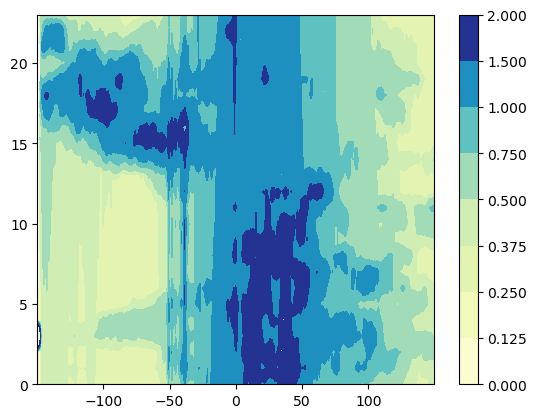

In [43]:
# plot=mean_rr_ne.rainrate.compute()
plt.contourf(mean_rr_ne.x.values,mean_rr_ne.hour.values,plot.mean('y'),levels=[0,0.125,0.250,0.375,0.5,0.75,1,1.5,2],cmap='YlGnBu')
plt.colorbar(extend=True)

In [24]:
# Step 2 — load and mask (fast, run each session)
cairns_ds = mask_radar_data(SITES['cairns']['zarr_path'], cairns=True)
# willis_ds = mask_radar_data(SITES['willis']['zarr_path'], cairns=False).chunk({'time': 100, 'y': -1, 'x': -1})

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.21 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
cairns_ds.groupby('time.hour').mean('time').plot()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


# Using zarr files

In [8]:
BASE = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig7_12LST_windregime_def'
sites   = ['cairns', 'willis']
regimes = ['nw', 'ne', 'se', 'sw']

# Build paths
radar_paths = {
    site: {regime: f"{BASE}/{site}_{regime}_hovmoller.zarr" for regime in regimes}
    for site in sites
}

lon_coords = {
    'cairns': xr.open_dataarray('/home/563/ac9768/GBR/scripts/Paper_figures/radar_anc/cairns_radar_lon.nc').values,
    'willis': xr.open_dataarray('/home/563/ac9768/GBR/scripts/Paper_figures/radar_anc/willis_radar_lon.nc').values,
}
lon_centers = {
    'cairns': (144.27374 + 147.09222) / 2,
    'willis': (148.55927 + 151.36993) / 2,
}

def open_hovmoller(path: str, lon_center: float, lon_x: np.ndarray) -> xr.DataArray:
    """Open hovmoller zarr, shift to LST, roll and double for 48h plotting."""
    offset_hours = round(lon_center * 4 / 60)
    ds = xr.open_zarr(path, chunks='auto')

    # Roll data AND coords together by the LST offset
    ds = ds.roll(hour=offset_hours, roll_coords=False)

    # Replace x coordinate with longitude values
    ds = ds.assign_coords(x=lon_x).rename({'x': 'lon'})

    return ds

# Open all zarr
results = {
    site: {
        regime: open_hovmoller(path, lon_centers[site], lon_coords[site])
        for regime, path in regime_dict.items()
        if os.path.exists(path)
    }
    for site, regime_dict in radar_paths.items()
}

/jobfs/168313098.gadi-pbs/ipykernel_532523/3112411068.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


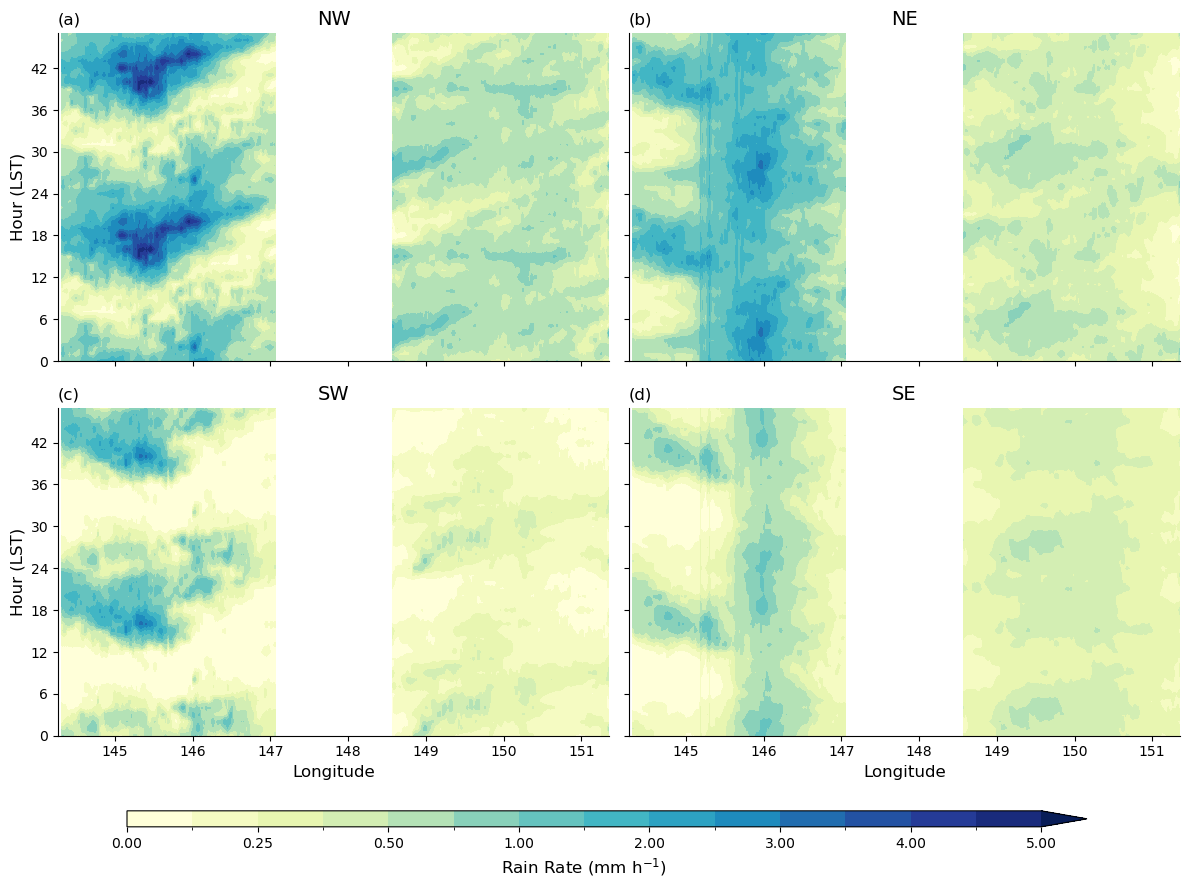

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, sharex=True)
fig.patch.set_facecolor('white')

regimes   = ['nw', 'ne', 'sw', 'se']
titles    = {'nw': 'NW', 'ne': 'NE', 'sw': 'SW', 'se': 'SE'}
labels    = {'nw': '(a)', 'ne': '(b)', 'sw': '(c)', 'se': '(d)'}
levels_rr = [0, 0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5,5]
cmap_rr   = 'YlGnBu'
norm_rr   = matplotlib.colors.BoundaryNorm(levels_rr, plt.cm.YlGnBu.N, extend='max')

for ax, regime in zip(axes.flat, regimes):
    # --- Cairns ---
    da_c = results['cairns'][regime].rainrate.compute()
    hours_48  = np.concatenate([da_c.hour.values, da_c.hour.values + 24])
    rain_48_c = np.concatenate([da_c.values, da_c.values], axis=0)
    im = ax.contourf(da_c.lon.values, hours_48, rain_48_c,
                     levels=levels_rr, cmap=cmap_rr, norm=norm_rr)

    # --- Willis ---
    da_w = results['willis'][regime].rainrate.compute()
    hours_48_w  = np.concatenate([da_w.hour.values, da_w.hour.values + 24])
    rain_48_w   = np.concatenate([da_w.values, da_w.values], axis=0)
    ax.contourf(da_w.lon.values, hours_48_w, rain_48_w,
                levels=levels_rr, cmap=cmap_rr, norm=norm_rr)

    # ax.axvline(145.9, color='black', linestyle='--', linewidth=0.8, alpha=0.7)  # Cairns radar
    # ax.axvline(149.5, color='grey',  linestyle='--', linewidth=0.8, alpha=0.7)  # Willis radar
    ax.set_title(titles[regime], fontsize=14)
    ax.set_title(labels[regime], loc='left', fontsize=12)
    ax.set_yticks(np.arange(0, 48, 6))
    ax.spines[['top', 'right']].set_visible(False)

axes[1, 0].set_xlabel('Longitude', fontsize=12)
axes[1, 1].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Hour (LST)', fontsize=12)
axes[1, 0].set_ylabel('Hour (LST)', fontsize=12)

cax  = fig.add_axes([0.11, -0.04, 0.8, 0.02])
sm   = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', extend='max')
cbar.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=12)

plt.tight_layout()
plt.show()

/jobfs/167457700.gadi-pbs/ipykernel_1503331/767896292.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


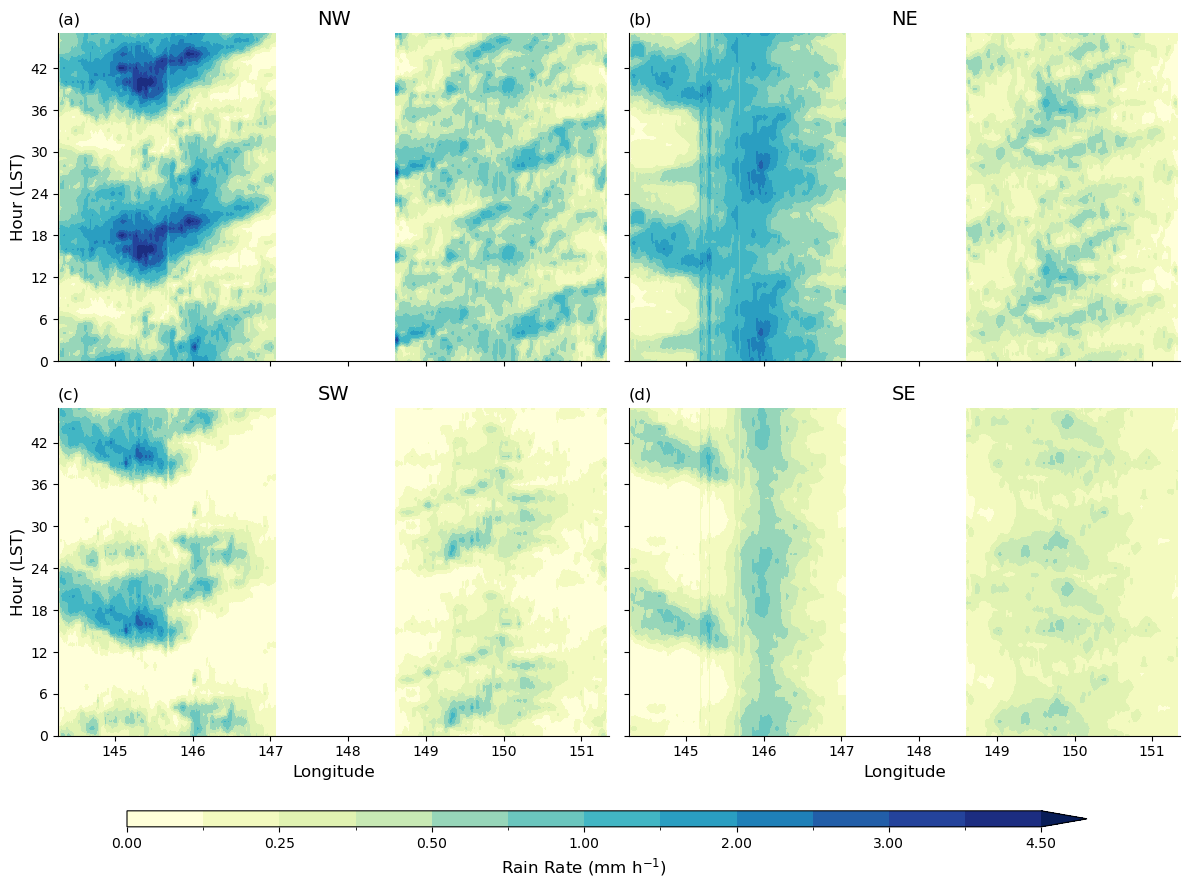

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, sharex=True)
fig.patch.set_facecolor('white')

regimes   = ['nw', 'ne', 'sw', 'se']
titles    = {'nw': 'NW', 'ne': 'NE', 'sw': 'SW', 'se': 'SE'}
labels    = {'nw': '(a)', 'ne': '(b)', 'sw': '(c)', 'se': '(d)'}
levels_rr = [0, 0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5, 2, 2.5, 3, 3.5, 4.5]
cmap_rr   = 'YlGnBu'
norm_rr   = matplotlib.colors.BoundaryNorm(levels_rr, plt.cm.YlGnBu.N, extend='max')

for ax, regime in zip(axes.flat, regimes):
    # --- Cairns ---
    da_c = results['cairns'][regime].rainrate.compute()
    hours_48  = np.concatenate([da_c.hour.values, da_c.hour.values + 24])
    rain_48_c = np.concatenate([da_c.values, da_c.values], axis=0)
    im = ax.contourf(da_c.lon.values, hours_48, rain_48_c,
                     levels=levels_rr, cmap=cmap_rr, norm=norm_rr)

    # --- Willis ---
    da_w = results['willis'][regime].rainrate.compute()
    hours_48_w  = np.concatenate([da_w.hour.values, da_w.hour.values + 24])
    rain_48_w   = np.concatenate([da_w.values, da_w.values], axis=0)
    ax.contourf(da_w.lon.values, hours_48_w, rain_48_w,
                levels=levels_rr, cmap=cmap_rr, norm=norm_rr)

    # ax.axvline(145.9, color='black', linestyle='--', linewidth=0.8, alpha=0.7)  # Cairns radar
    # ax.axvline(149.5, color='grey',  linestyle='--', linewidth=0.8, alpha=0.7)  # Willis radar
    ax.set_title(titles[regime], fontsize=14)
    ax.set_title(labels[regime], loc='left', fontsize=12)
    ax.set_yticks(np.arange(0, 48, 6))
    ax.spines[['top', 'right']].set_visible(False)

axes[1, 0].set_xlabel('Longitude', fontsize=12)
axes[1, 1].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Hour (LST)', fontsize=12)
axes[1, 0].set_ylabel('Hour (LST)', fontsize=12)

cax  = fig.add_axes([0.11, -0.04, 0.8, 0.02])
sm   = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', extend='max')
cbar.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=12)

plt.tight_layout()
plt.show()

# get satellite data

In [10]:
def him8_files(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith("_ch13BT_regridded_2kmres.nc"):  
                file_paths.append(os.path.join(root, file))
    return file_paths
directory = "/g/data/q90/ac9768/GBR/him8"
files = him8_files(directory)

In [12]:
# old wind times definition
# ds_barra = xr.open_mfdataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc',engine="netcdf4")
# ds_barra = ds_barra.sortby('time')
# ds_selected = ds_barra.sel(time=slice('2016-01-01', '2020-04-01'))
# barra = ds_selected.sel(time=~(ds_selected['time.month'] == 4))
# winds = barra.wind_dir.compute()
# def wind_times(winds):    
#     ne = winds[(winds>=0)&(winds<=90)].time.values
#     se = winds[(winds>90)&(winds<=180)].time.values
#     sw = winds[(winds>180)&(winds<=270)].time.values
#     nw = winds[(winds>270)&(winds<=360)].time.values
#     return ne,se,sw,nw
# ne,se,sw,nw = wind_times(winds)

In [13]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [14]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ds_barra = xr.open_mfdataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc',engine="netcdf4")
ds_barra = ds_barra.sortby('time')
ds_selected = ds_barra.sel(time=slice('2016-01-01', '2020-04-01'))
barra = ds_selected.sel(time=~(ds_selected['time.month'] == 4))
ne, se, sw, nw = wind_times(barra, lon_cairns)

In [15]:
def read_netcdf_him8(file_path,wind_times):
    with xr.open_mfdataset(file_path,engine="h5netcdf", chunks="auto") as ds:
        barra_winds = ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-17,-16.6)) 
        result_mean = barra_winds.groupby(barra_winds.time.dt.hour).mean(dim=["lat","time"]) 
    return result_mean 

In [16]:
ne_him_mean = read_netcdf_him8(files,ne)
se_him_mean = read_netcdf_him8(files,se)
sw_him_mean = read_netcdf_him8(files,sw)
nw_him_mean = read_netcdf_him8(files,nw)

In [17]:
ne_result_mean = ne_him_mean.compute()
se_result_mean = se_him_mean.compute()
sw_result_mean = sw_him_mean.compute()
nw_result_mean = nw_him_mean.compute()

In [18]:
def utc_to_lst_shift_him8(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)  # degrees → minutes → hours
    # Shift data values along the time axis (dask-safe, no compute triggered)
    ds_shifted = ds.roll(hour=offset_hours, roll_coords=True)
    return ds_shifted

In [19]:
ne_bt_mean_aedt = utc_to_lst_shift_him8(ne_result_mean,lon_cairns)
se_bt_mean_aedt = utc_to_lst_shift_him8(se_result_mean,lon_cairns)
sw_bt_mean_aedt = utc_to_lst_shift_him8(sw_result_mean,lon_cairns)
nw_bt_mean_aedt = utc_to_lst_shift_him8(nw_result_mean,lon_cairns)

In [20]:
# ne_bt_mean_aedt = np.roll(ne_result_mean,shift=11,axis=0)
# se_bt_mean_aedt = np.roll(se_result_mean,shift=11,axis=0)
# sw_bt_mean_aedt = np.roll(sw_result_mean,shift=11,axis=0)
# nw_bt_mean_aedt = np.roll(nw_result_mean,shift=11,axis=0)

In [21]:
bt_long = xr.open_dataset('/g/data/q90/ac9768/GBR/him8/2020_ch13BT_regridded_2kmres.nc', engine="h5netcdf", chunks="auto")
bt_lon = bt_long.lon.load().values

# Plot satellite and radar

In [22]:
# double all arrays to plot between 48 hours
def double_array(arr):
    return np.concatenate([arr, arr])

ne_double_him_mean = double_array(ne_bt_mean_aedt)
se_double_him_mean = double_array(se_bt_mean_aedt)
sw_double_him_mean = double_array(sw_bt_mean_aedt)
nw_double_him_mean = double_array(nw_bt_mean_aedt)

In [25]:
# old radar plotting
# load data for plotting
# for domain in results:
#     for regime in results[domain]:
#         results[domain][regime] = results[domain][regime].load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 19.58 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 40.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/cli

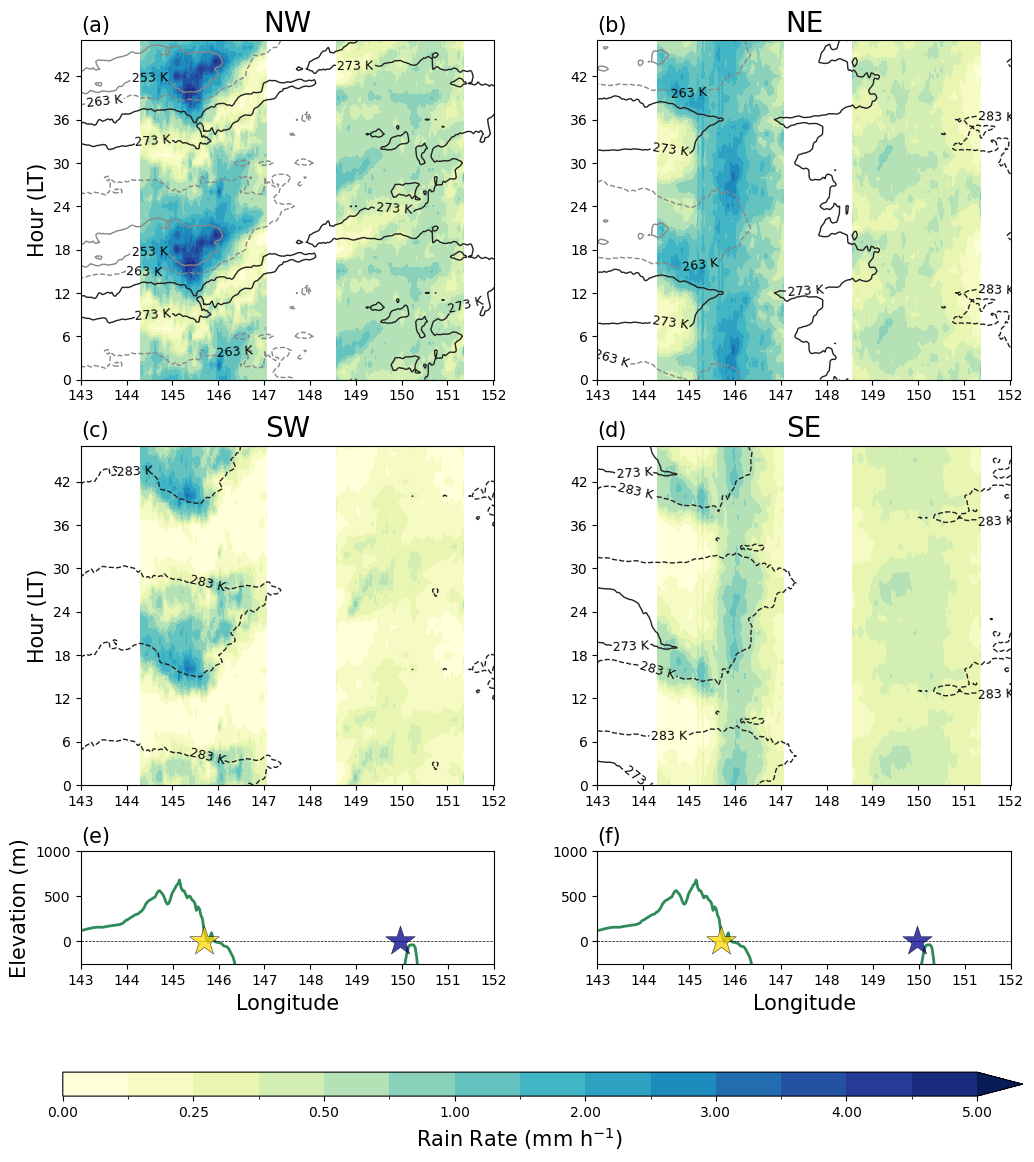

In [25]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(12, 12))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[3, 3, 1], hspace=0.25, wspace=0.25)

ax = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])
ax_bot = [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]

# plot data
levels_h8 = np.arange(241, 305, 2.5)
levels_rr = [0, 0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5, 2,2.5,3,3.5,4,4.5,5]
alpha_rr  = 1#0.75
light_grey = '#888888'
dark_grey  = '#222222'

cmap_h8 = matplotlib.cm.binary
cmap_rr = matplotlib.cm.YlGnBu
norm    = matplotlib.colors.BoundaryNorm(levels_h8, cmap_h8.N, extend='both')
norm_rr = matplotlib.colors.BoundaryNorm(levels_rr, cmap_rr.N, extend='max')

# x values for BT
bt_long = xr.open_dataset('/g/data/q90/ac9768/GBR/him8/2020_ch13BT_regridded_2kmres.nc', engine="h5netcdf", chunks="auto")
bt_lon  = bt_long.lon.values
time    = np.arange(0, 48, 1)

# regime order matching ax layout: [0,0]=NW, [0,1]=NE, [1,0]=SW, [1,1]=SE
regime_ax_map = [
    (ax[0, 0], 'nw', nw_double_him_mean, '(a)', 'NW'),
    (ax[0, 1], 'ne', ne_double_him_mean, '(b)', 'NE'),
    (ax[1, 0], 'sw', sw_double_him_mean, '(c)', 'SW'),
    (ax[1, 1], 'se', se_double_him_mean, '(d)', 'SE'),
]

for a, regime, him_mean, label, title in regime_ax_map:

    # --- Cairns radar ---
    da_c      = results['cairns'][regime].rainrate.compute()
    hours_48  = np.concatenate([da_c.hour.values, da_c.hour.values + 24])
    rain_48_c = np.concatenate([da_c.values, da_c.values], axis=0)
    a.contourf(da_c.lon.values, hours_48, rain_48_c,
               levels=levels_rr, cmap=cmap_rr, norm=norm_rr, alpha=alpha_rr)

    # --- Willis radar ---
    da_w      = results['willis'][regime].rainrate.compute()
    hours_48_w = np.concatenate([da_w.hour.values, da_w.hour.values + 24])
    rain_48_w  = np.concatenate([da_w.values, da_w.values], axis=0)
    a.contourf(da_w.lon.values, hours_48_w, rain_48_w,
               levels=levels_rr, cmap=cmap_rr, norm=norm_rr, alpha=alpha_rr)

    # --- BT contours ---
    c253 = a.contour(bt_lon, time, him_mean, levels=[253], colors=light_grey, linewidths=1, linestyles='-')
    c263 = a.contour(bt_lon, time, him_mean, levels=[263], colors=light_grey, linewidths=1, linestyles='--')
    c273 = a.contour(bt_lon, time, him_mean, levels=[273], colors=dark_grey,  linewidths=1, linestyles='-')
    c283 = a.contour(bt_lon, time, him_mean, levels=[283], colors=dark_grey,  linewidths=1, linestyles='--')

    for c, clabel in zip([c253, c263, c273, c283], ['253 K', '263 K', '273 K', '283 K']):
        a.clabel(c, fmt={c.levels[0]: clabel}, colors='black', fontsize=9, inline=True, inline_spacing=2)

    a.set_title(title, fontsize=20)
    a.set_title(label, loc='left', fontsize=15)
    a.set_yticks(np.arange(0, 48, 6))
    a.set_xticks(np.arange(143,153,1))

# --- bottom row ---
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part', engine="netcdf4")
ds_bath = ds_full.sel(x=slice(140, 155), y=slice(-22, -11))
bath_mean = ds_bath['z'].sel(y=slice(-16.993225, -16.633728)).mean(dim='y')
long = ds_bath.sel(y=-16.8, method='nearest').drop_vars('z')

lon_cairns_site = 145.683
lon_willis_site = 149.96

for a in ax_bot:
    a.plot(long.x, bath_mean, color='seagreen', linewidth=2)
    a.axhline(0, color='black', alpha=1, linestyle='--', linewidth=0.5)
    a.set_xlabel("Longitude", fontsize=15)
    a.set_ylim(-250, 1000)
    a.set_xlim(143, 152)
    a.scatter(lon_cairns_site, 0, marker='*', color='gold', s=500,alpha=0.75,
              zorder=5, edgecolors='black', linewidths=0.4, label='Cairns radar')
    a.scatter(lon_willis_site, 0, marker='*', color='darkblue', s=500,alpha=0.75,
              zorder=5, edgecolors='black', linewidths=0.4, label='Willis radar')
ax_bot[0].set_title('(e)', loc='left', fontsize=15)
ax_bot[1].set_title('(f)', loc='left', fontsize=15)

ax_bot[0].set_ylabel("Elevation (m)", fontsize=15)

# --- colorbars ---
dax = fig.add_axes([0.11, -0.0, 0.8, 0.02])
sm_rr = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm_rr.set_array([])
cbar_rr = fig.colorbar(sm_rr, cax=dax, orientation='horizontal', alpha=alpha_rr)
cbar_rr.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=15)

# --- BT legend ---
# bt_legend_elements = [
#     Line2D([0], [0], color=light_grey, linewidth=1, linestyle='-',  label='253 K'),
#     Line2D([0], [0], color=light_grey, linewidth=1, linestyle='--', label='263 K'),
#     Line2D([0], [0], color=dark_grey,  linewidth=1, linestyle='-',  label='273 K'),
#     Line2D([0], [0], color=dark_grey,  linewidth=1, linestyle='--', label='283 K'),
# ]
# fig.legend(handles=bt_legend_elements, title='Ch.13 BT',
#            loc='lower center', bbox_to_anchor=(0.5, -0.04),
#            ncol=4, frameon=False, fontsize=12, title_fontsize=12)

# --- axis labels ---
ax[0, 0].set_ylabel("Hour (LT)", fontsize=15)
ax[1, 0].set_ylabel("Hour (LT)", fontsize=15)

plt.show()
fig.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/f07v4.png',bbox_inches='tight',dpi=300)

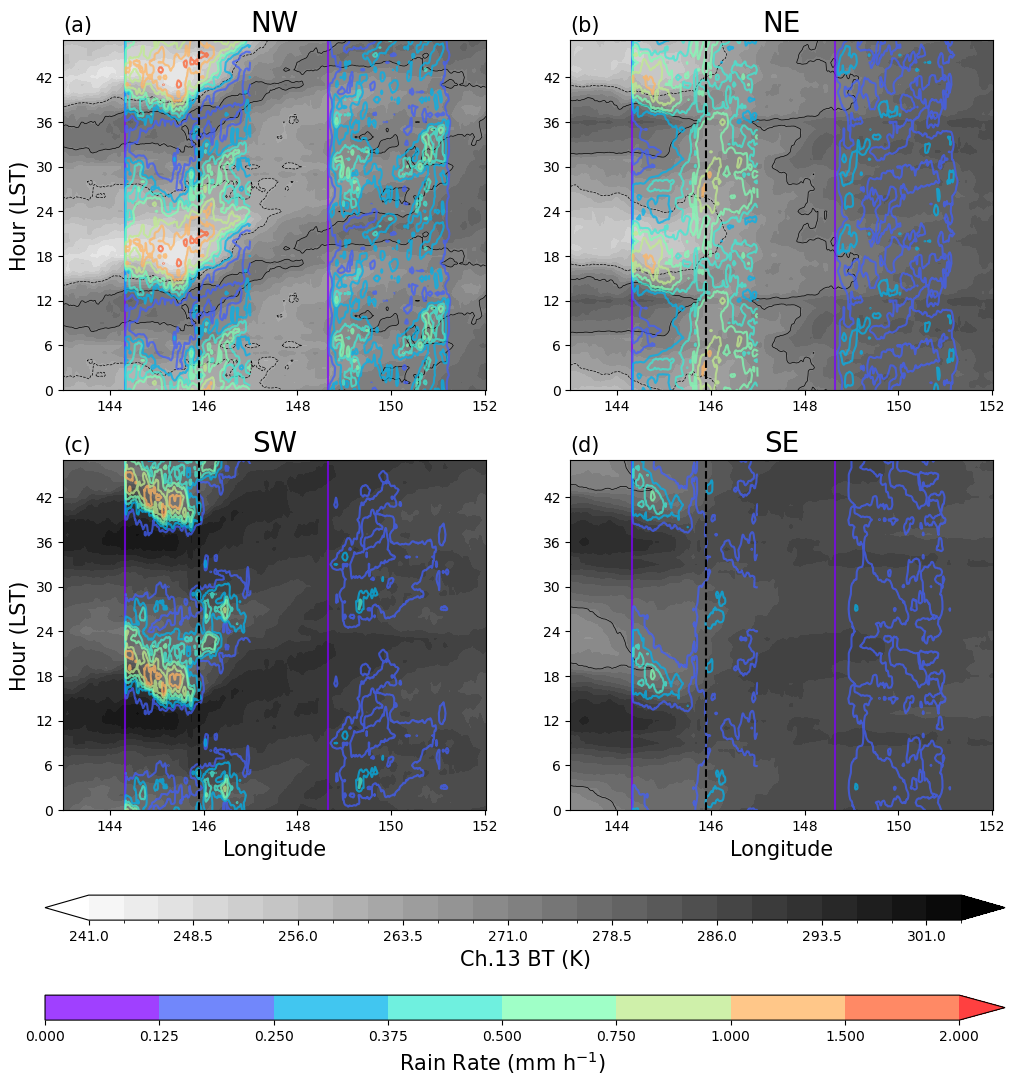

In [26]:
# figure without orography
# setup figure
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(2,2,figsize=(12,10))
fig.patch.set_facecolor('white')

# plot data
levels_h8 = np.arange(241,305,2.5)
levels_rr = np.arange(0,2,0.1)
levels_rr = [0,0.125,0.25,0.375,0.5,0.75,1,1.5,2]
alpha_rr = 0.75

# levels_rr = np.logspace(np.log10(0.01), np.log10(2.25), num=8)
cmap_h8 = matplotlib.cm.binary
cmap_rr = matplotlib.cm.rainbow # YlGnBu
norm = matplotlib.colors.BoundaryNorm(levels_h8, cmap_h8.N, extend='both')
norm_rr = matplotlib.colors.BoundaryNorm(levels_rr, cmap_rr.N,extend='max')  # , extend='max' if needed
# norm_rr = LogNorm(vmin=levels_rr[0], vmax=levels_rr[-1])

# x values
bt_long = xr.open_dataset('/g/data/q90/ac9768/GBR/him8/2020_ch13BT_regridded_2kmres.nc', engine="h5netcdf", chunks="auto")
bt_lon = bt_long.lon.values
x_cairns = xr.open_dataset(cairns_radar_files[0]).longitude.sel(x=slice(-150000,140000)).mean('y').values
x_willis = xr.open_dataset(willis_radar_files[0]).longitude.sel(x=slice(-150000,140000)).mean('y').values

# y values
time = np.arange(0,48,1)

# z values
ax[0,1].contourf(bt_lon,time,ne_double_him_mean,levels=levels_h8,cmap=cmap_h8,alpha=1)
ax[0,1].contour(bt_lon,time,ne_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,1].contour(bt_lon,time,ne_double_him_mean,levels=[263],colors="black",alpha=1,linewidths=0.5,linestyles='--')
ax[0,1].contour(x_cairns,time,results['cairns']['ne'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)
ax[0,1].contour(x_willis,time,results['willis']['ne'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)

ax[1,1].contourf(bt_lon,time,se_double_him_mean,levels=levels_h8,cmap=cmap_h8,alpha=1)
ax[1,1].contour(bt_lon,time,se_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[1,1].contour(x_cairns,time,results['cairns']['se'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)
ax[1,1].contour(x_willis,time,results['willis']['se'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)

ax[1,0].contourf(bt_lon,time,sw_double_him_mean,levels=levels_h8,cmap=cmap_h8,alpha=1)
ax[1,0].contour(bt_lon,time,sw_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[1,0].contour(x_cairns,time,results['cairns']['sw'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)
ax[1,0].contour(x_willis,time,results['willis']['sw'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)

ax[0,0].contourf(bt_lon,time,nw_double_him_mean,levels=levels_h8,cmap=cmap_h8,alpha=1)
ax[0,0].contour(bt_lon,time,nw_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,0].contour(bt_lon,time,nw_double_him_mean,levels=[263],colors="black",alpha=1,linewidths=0.5,linestyles='--')
ax[0,0].contour(x_cairns,time,results['cairns']['nw'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)
ax[0,0].contour(x_willis,time,results['willis']['nw'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)

# colorbars
cax = fig.add_axes([0.11, 0, 0.8, 0.025])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_h8)
sm.set_array([])  # Empty array since data is already in the norm
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(label='Ch.13 BT (K)', fontsize=15)

dax = fig.add_axes([0.11, -0.1, 0.8, 0.025])  # [left, bottom, width, height]
norm_rr = matplotlib.colors.BoundaryNorm(levels_rr, cmap_rr.N,extend='max')  # , extend='max' if needed
sm_rr = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm_rr.set_array([])
cbar_rr = fig.colorbar(sm_rr, cax=dax, orientation='horizontal',alpha=alpha_rr)
cbar_rr.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=15)

# other plot details
ax[1,1].set_xlabel("Longitude",fontsize=15)
ax[1,0].set_xlabel("Longitude",fontsize=15)
ax[1,0].set_ylabel("Hour (LST)",fontsize=15)
ax[0,0].set_ylabel("Hour (LST)",fontsize=15)

ax[0,1].set_title("NE",fontsize=20)
ax[0, 1].set_title("(b)", loc="left", fontsize=15)

ax[1,1].set_title("SE",fontsize=20)
ax[1, 1].set_title("(d)", loc="left", fontsize=15)

ax[1,0].set_title("SW",fontsize=20)
ax[1, 0].set_title("(c)", loc="left", fontsize=15)

ax[0,0].set_title("NW",fontsize=20)
ax[0, 0].set_title("(a)", loc="left", fontsize=15)

for ax in ax.flat:
    ax.set_yticks(np.arange(0,48,6))
    ax.axvline(145.9,color='black',alpha=1,linestyle='--')
    # ax.grid(linestyle='--',alpha=0.5)
fig.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/f07_ref-radar.png',bbox_inches='tight',dpi=300)

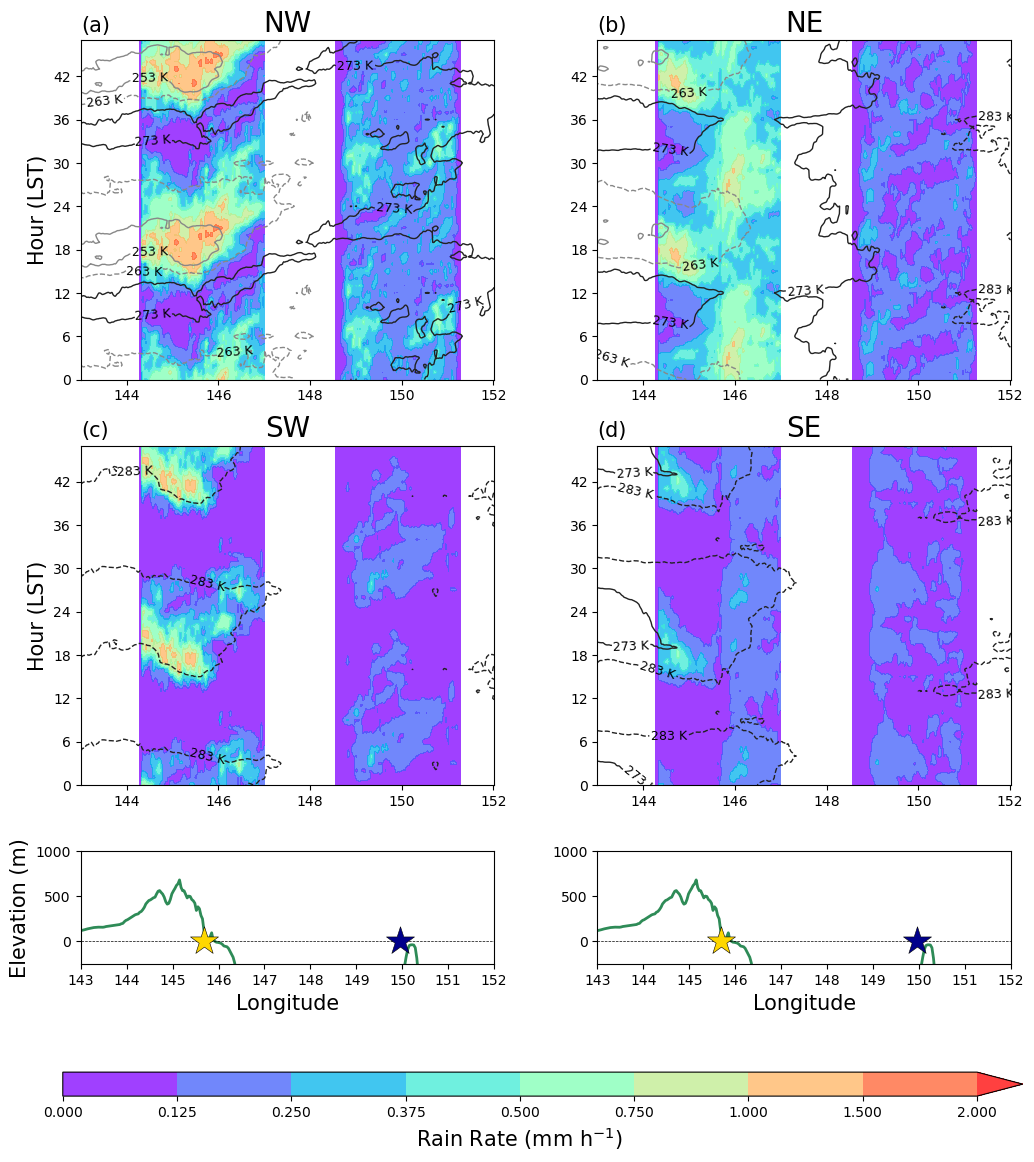

In [64]:
# add topography as subpanels below - 

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(12, 12))
fig.patch.set_facecolor('white')

# 3 rows: 2 main (equal height) + 1 narrow (1/3 height)
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[3, 3, 1], hspace=0.25, wspace=0.25)

ax = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])
ax_bot = [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]

# plot data
levels_h8 = np.arange(241, 305, 2.5)
levels_rr = [0, 0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5, 2]
alpha_rr = 0.75

cmap_h8 = matplotlib.cm.binary
cmap_rr = matplotlib.cm.rainbow
norm    = matplotlib.colors.BoundaryNorm(levels_h8, cmap_h8.N, extend='both')
norm_rr = matplotlib.colors.BoundaryNorm(levels_rr, cmap_rr.N, extend='max')

# x values
bt_long = xr.open_dataset('/g/data/q90/ac9768/GBR/him8/2020_ch13BT_regridded_2kmres.nc', engine="h5netcdf", chunks="auto")
bt_lon  = bt_long.lon.values
x_cairns = xr.open_dataset(cairns_radar_files[0]).longitude.sel(x=slice(-150000, 140000)).mean('y').values
x_willis = xr.open_dataset(willis_radar_files[0]).longitude.sel(x=slice(-150000, 140000)).mean('y').values

time = np.arange(0, 48, 1)

# --- main 4-panel plots (unchanged) ---
# ax[0,1].contourf(bt_lon, time, ne_double_him_mean, levels=levels_h8, cmap=cmap_h8, alpha=1)
ax[0,1].contourf(x_cairns, time, results['cairns']['ne'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)
ax[0,1].contourf(x_willis, time, results['willis']['ne'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)

# ax[1,1].contourf(bt_lon, time, se_double_him_mean, levels=levels_h8, cmap=cmap_h8, alpha=1)
ax[1,1].contourf(x_cairns, time, results['cairns']['se'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)
ax[1,1].contourf(x_willis, time, results['willis']['se'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)

# ax[1,0].contourf(bt_lon, time, sw_double_him_mean, levels=levels_h8, cmap=cmap_h8, alpha=1)
ax[1,0].contourf(x_cairns, time, results['cairns']['sw'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)
ax[1,0].contourf(x_willis, time, results['willis']['sw'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)

# ax[0,0].contourf(bt_lon, time, nw_double_him_mean, levels=levels_h8, cmap=cmap_h8, alpha=1)
ax[0,0].contourf(x_cairns, time, results['cairns']['nw'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)
ax[0,0].contourf(x_willis, time, results['willis']['nw'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)

for a, him_mean in zip(ax.flat, [nw_double_him_mean, ne_double_him_mean, sw_double_him_mean, se_double_him_mean]):
    c253 = a.contour(bt_lon, time, him_mean, levels=[253], colors='#888888', linewidths=1, linestyles='-')
    c263 = a.contour(bt_lon, time, him_mean, levels=[263], colors='#888888', linewidths=1, linestyles='--')
    c273 = a.contour(bt_lon, time, him_mean, levels=[273], colors='#222222',  linewidths=1, linestyles='-')
    c283 = a.contour(bt_lon, time, him_mean, levels=[283], colors='#222222',  linewidths=1, linestyles='--')

    for c, label in zip([c253, c263, c273, c283], ['253 K', '263 K', '273 K', '283 K']):
        a.clabel(c, fmt={c.levels[0]: label}, colors='black',fontsize=9, inline=True, inline_spacing=2)

# --- bottom row (1/3 height) — 
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))

long=ds_bath.sel(y=-16.8,method='nearest').drop_vars('z')
ax_bot[0].plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
ax_bot[1].plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
ax_bot[0].set_ylabel("Elevation (m)",fontsize=15)

lon_cairns_site = 145.683  
lon_willis_site = 149.96

for a in ax_bot:
    a.axhline(-0, color='black', alpha=1, linestyle='--',linewidth=0.5)
    a.set_xlabel("Longitude",fontsize=15)
    a.set_ylim(-250,1000)
    a.set_xlim(143,152)
    a.scatter(lon_cairns_site, 0, marker='*', color='gold', s=450,
              zorder=5, edgecolors='black', linewidths=0.4, label='Radar site')
    a.scatter(lon_willis_site, 0, marker='*', color='darkblue', s=450,
              zorder=5, edgecolors='black', linewidths=0.4)

# --- colorbars ---
# cax = fig.add_axes([0.11, 0.0, 0.8, 0.02])
# sm  = plt.cm.ScalarMappable(norm=norm, cmap=cmap_h8)
# sm.set_array([])
# cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
# cbar.set_label('Ch.13 BT (K)', fontsize=15)
# bt_legend_elements = [
#     Line2D([0], [0], color='#888888', linewidth=2, linestyle='-', label='253 K'),
#     Line2D([0], [0], color='#888888', linewidth=2, linestyle='--', label='263 K'),
#     Line2D([0], [0], color='#222222', linewidth=2, linestyle='-',  label='273 K'),
#     Line2D([0], [0], color='#222222', linewidth=2, linestyle='--',  label='283 K'),
# ]

# fig.legend(
#     handles=bt_legend_elements,
#     title='Ch.13 BT',
#     loc='lower center',
#     bbox_to_anchor=(0.5, -0.02),
#     ncol=4,
#     frameon=True,
#     fontsize=14,
#     title_fontsize=15,
# )
dax = fig.add_axes([0.11, -0.0, 0.8, 0.02])# if legend =-0.08
sm_rr = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm_rr.set_array([])
cbar_rr = fig.colorbar(sm_rr, cax=dax, orientation='horizontal', alpha=alpha_rr)
cbar_rr.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=15)

# --- labels and titles ---
# ax[1,1].set_xlabel("Longitude", fontsize=15)
# ax[1,0].set_xlabel("Longitude", fontsize=15)
ax[1,0].set_ylabel("Hour (LST)", fontsize=15)
ax[0,0].set_ylabel("Hour (LST)", fontsize=15)

ax[0,1].set_title("NE", fontsize=20)
ax[0,1].set_title("(b)", loc="left", fontsize=15)
ax[1,1].set_title("SE", fontsize=20)
ax[1,1].set_title("(d)", loc="left", fontsize=15)
ax[1,0].set_title("SW", fontsize=20)
ax[1,0].set_title("(c)", loc="left", fontsize=15)
ax[0,0].set_title("NW", fontsize=20)
ax[0,0].set_title("(a)", loc="left", fontsize=15)

for a in ax.flat:
    a.set_yticks(np.arange(0, 48, 6))
    # a.axvline(145.9, color='black', alpha=1, linestyle='--')

fig.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/f07_ref-radar-topog-formatchanges-inlinev4.png',bbox_inches='tight',dpi=300)

In [29]:
bt_long

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 2167, lat: 446, lon: 502)
Coordinates:
  * time     (time) datetime64[ns] 17kB 2020-01-01 ... 2020-03-31T23:00:00
  * lat      (lat) float64 4kB -22.0 -21.98 -21.96 ... -14.03 -14.01 -13.99
  * lon      (lon) float64 4kB 143.0 143.0 143.0 143.1 ... 152.0 152.0 152.0
Data variables:
    ch13BT   (time, lat, lon) float32 2GB dask.array<chunksize=(149, 446, 502), meta=np.ndarray>
Attributes:
    note:     2017 JFM ch13BT with smaller domain ~11km spatial resolution, f...

# adding topography on contours

In [47]:
# open topography dataset
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))

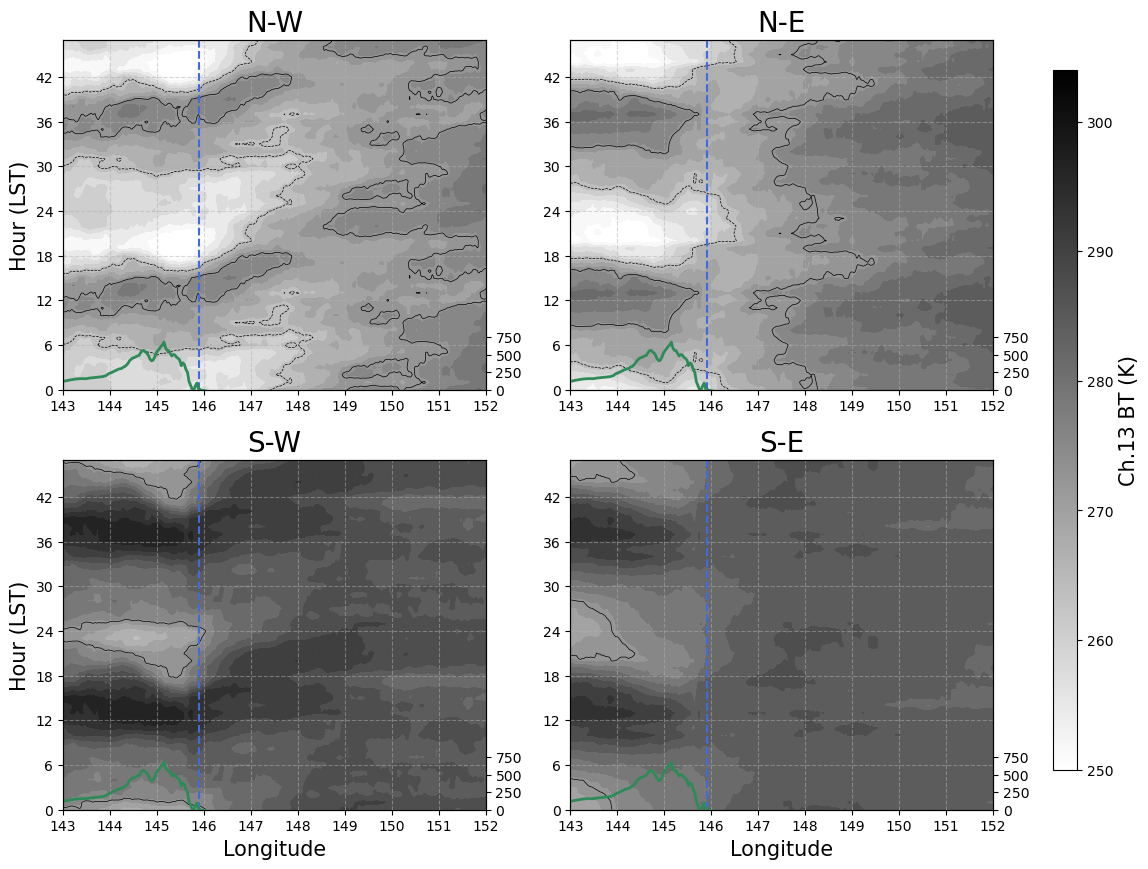

In [52]:
# topo
fig, ax = plt.subplots(2,2,figsize=(12,10))
fig.patch.set_facecolor('white')
levels=np.arange(250,305,3)
ax[0,1].contourf(bt_lon,np.arange(0,48,1),ne_double_him_mean,levels=levels,cmap="binary",alpha=1)
ax[0,1].contour(bt_lon,np.arange(0,48,1),ne_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,1].contour(bt_lon,np.arange(0,48,1),ne_double_him_mean,levels=[263],colors="black",alpha=1,linewidths=0.5,linestyles='--')
ax[1,1].contourf(bt_lon,np.arange(0,48,1),se_double_him_mean,levels=levels,cmap="binary",alpha=1)
ax[1,1].contour(bt_lon,np.arange(0,48,1),se_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[1,0].contourf(bt_lon,np.arange(0,48,1),sw_double_him_mean,levels=levels,cmap="binary",alpha=1)
ax[1,0].contour(bt_lon,np.arange(0,48,1),sw_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,0].contourf(bt_lon,np.arange(0,48,1),nw_double_him_mean,levels=levels,cmap="binary",alpha=1)
ax[0,0].contour(bt_lon,np.arange(0,48,1),nw_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,0].contour(bt_lon,np.arange(0,48,1),nw_double_him_mean,levels=[263],colors="black",alpha=1,linewidths=0.5,linestyles='--')

cax = fig.add_axes([0.95, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
# # Create a colorbar using the ScalarMappable from one of the subplots
sm = plt.cm.ScalarMappable(cmap="binary")
sm.set_array(levels)  # You need to set an array for the ScalarMappable
cbar = plt.colorbar(sm,cax=cax)
cbar.set_label(label='Ch.13 BT (K)',fontsize=15)

# plot topography
# make twin axis for topography overlay
ax1 = ax[0,0].twinx()
ax1.set_ylim(0,5000)
ax1.set_yticks(np.arange(0,1000,250))
ax1.set_xlim(143,152)
ax2 = ax[0,1].twinx()
ax2.set_ylim(0,5000)
ax2.set_yticks(np.arange(0,1000,250))
ax2.set_xlim(143,152)
ax3 = ax[1,0].twinx()
ax3.set_ylim(0,5000)
ax3.set_yticks(np.arange(0,1000,250))
ax3.set_xlim(143,152)
ax4 = ax[1,1].twinx()
ax4.set_ylim(0,5000)
ax4.set_yticks(np.arange(0,1000,250))
ax4.set_xlim(143,152)
long=ds_bath.sel(y=-16.8,method='nearest').drop_vars('z')
ax1.plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
# ax1.plot(long.x,ds_bath['z'].sel(y=-16.8,method='nearest'),color='seagreen',linewidth=2)
ax2.plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
ax3.plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
ax4.plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)

ax[1,1].set_xlabel("Longitude",fontsize=15)
ax[1,0].set_xlabel("Longitude",fontsize=15)
ax[1,0].set_ylabel("Hour (LST)",fontsize=15)
ax[0,0].set_ylabel("Hour (LST)",fontsize=15)
ax[0,0].set_yticks(np.arange(0,48,6))
ax[0,1].set_yticks(np.arange(0,48,6))
ax[1,0].set_yticks(np.arange(0,48,6))
ax[1,1].set_yticks(np.arange(0,48,6))
ax[0,1].set_title("N-E",fontsize=20)
ax[1,1].set_title("S-E",fontsize=20)
ax[1,0].set_title("S-W",fontsize=20)
ax[0,0].set_title("N-W",fontsize=20)
ax[0,1].axvline(145.9,color='royalblue',alpha=1,linestyle='--')
ax[1,1].axvline(145.9,color='royalblue',alpha=1,linestyle='--')
ax[1,0].axvline(145.9,color='royalblue',alpha=1,linestyle='--')
ax[0,0].axvline(145.9,color='royalblue',alpha=1,linestyle='--')
ax[0,1].grid(linestyle='--',alpha=0.5)
ax[1,1].grid(linestyle='--',alpha=0.5)
ax[1,0].grid(linestyle='--',alpha=0.5)
ax[0,0].grid(linestyle='--',alpha=0.5)

In [ ]:
len(wind_times)/24

In [ ]:
len(merged_500.time)/24

In [ ]:
def plot_barra_variables(barra_variable,level,cmap,scm,ne,se,sw,nw,cbar_label,title):
    fig, ax = plt.subplots(2,2,figsize=(8,8))
    fig.patch.set_facecolor('white')
    levels = level
    cf_ne = ax[0,1].contourf(barra_variable.lon,np.arange(0,48,1),ne,levels=levels,cmap=cmap)
    cf_se = ax[1,1].contourf(barra_variable.lon,np.arange(0,48,1),se,levels=levels,cmap=cmap)
    cf_sw = ax[1,0].contourf(barra_variable.lon,np.arange(0,48,1),sw,levels=levels,cmap=cmap)
    cf_nw = ax[0,0].contourf(barra_variable.lon,np.arange(0,48,1),nw,levels=levels,cmap=cmap)
    ax[0,1].contour(barra_variable.lon,np.arange(0,48,1),ne,levels=levels,colors="black",linewidths=1)
    ax[1,1].contour(barra_variable.lon,np.arange(0,48,1),se,levels=levels,colors="black",linewidths=1)
    ax[1,0].contour(barra_variable.lon,np.arange(0,48,1),sw,levels=levels,colors="black",linewidths=1)
    ax[0,0].contour(barra_variable.lon,np.arange(0,48,1),nw,levels=levels,colors="black",linewidths=1)
    # for colorbar plotting
    cax = fig.add_axes([1, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    # # Create a colorbar using the ScalarMappable from one of the subplots
    sm = plt.cm.ScalarMappable(cmap=scm)
    sm.set_array(levels)  # You need to set an array for the ScalarMappable
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label(cbar_label,fontsize=10)
    yticks = np.arange(0,48,6)
    ax[0,1].set_yticks(yticks)
    ax[1,1].set_yticks(yticks)
    ax[1,0].set_yticks(yticks)
    ax[0,0].set_yticks(yticks)
    
    ax[0,0].set_ylabel('Hour (AEST)')
    ax[1,0].set_ylabel('Hour (AEST)')
    ax[1,0].set_xlabel('Longitude')
    ax[1,1].set_xlabel('Longitude')
    
    ax[0,1].set_title("NE")
    ax[1,1].set_title("SE")
    ax[1,0].set_title("SW")
    ax[0,0].set_title("NW")
    fig.suptitle(title+' Regime Composites')
    return
plot_barra_variables(barra_cairns_rad,np.arange(0,1000,50),"plasma",plt.cm.plasma,sfc_ne,sfc_se,sfc_sw,sfc_nw,'W M-2','Cairns Surface Net SW Flux')